# Several views on cross-entropy — synthetic experiments

Companion notebook to the post. Each experiment isolates one idea:

1. **A coin** — maximum likelihood recovers the coin's bias; the negative
   log-likelihood *is* binary cross-entropy.
2. **The identity** — $H(p,q) = H(p) + D_{\mathrm{KL}}(p\|q)$, checked numerically.
3. **Calibration** — temperature scaling lowers cross-entropy while accuracy stays
   flat (cross-entropy scores calibration; accuracy doesn't).
4. **Forward vs. reverse KL** — fitting one Gaussian to a bimodal target.
5. **Why not MSE?** — squared error is also a proper scoring rule, but as an
   *optimization* objective on a sigmoid it has vanishing gradients exactly when
   the model is confidently wrong.

Pure `numpy` + `matplotlib`, styled to match the site.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# --- site theme -----------------------------------------------------------
BG, PANEL, LINE = "#0e1116", "#151a21", "#222a35"
FG, MUTED, ACCENT, ACCENT2 = "#d7dde6", "#8a94a3", "#4aa3ff", "#e0a458"

mpl.rcParams.update({
    "figure.facecolor": PANEL, "axes.facecolor": PANEL, "savefig.facecolor": PANEL,
    "axes.edgecolor": LINE, "axes.labelcolor": FG, "text.color": FG,
    "xtick.color": MUTED, "ytick.color": MUTED, "grid.color": LINE,
    "axes.grid": True, "grid.linewidth": 0.6, "grid.alpha": 0.7,
    "font.family": "monospace", "font.size": 11, "figure.dpi": 120,
    "axes.titlesize": 12, "legend.frameon": False, "legend.labelcolor": FG,
})

def style(ax):
    """Hide top/right spines, color the rest — the house look."""
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(LINE)
    return ax

rng = np.random.default_rng(0)
eps = 1e-12  # keeps logs finite

## 1. A coin: maximum likelihood = minimizing cross-entropy

Flip a biased coin $n$ times. For a candidate bias $p$, the negative log-likelihood is

$$ \text{NLL}(p) = -\big[k \log p + (n-k)\log(1-p)\big], \qquad k = \#\text{heads}. $$

This is binary cross-entropy with a constant prediction $p$. Its minimum sits exactly
at the empirical frequency $k/n$, and as $n$ grows that estimate converges to the true
bias.

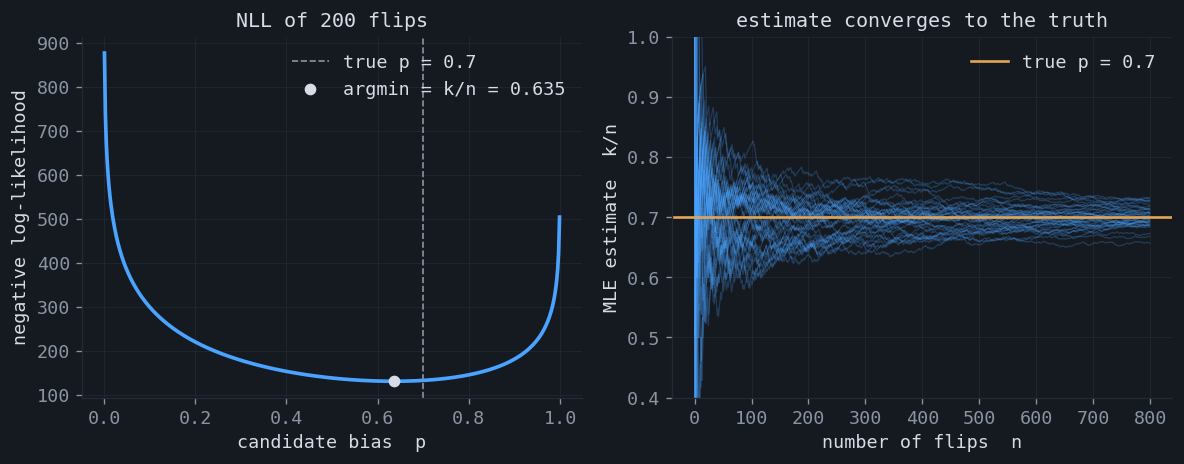

closed-form MLE  k/n = 0.635   (true 0.7)


In [2]:
true_p = 0.7
n = 200
flips = (rng.random(n) < true_p).astype(int)
k = flips.sum()

p_grid = np.linspace(1e-3, 1 - 1e-3, 500)
nll = -(k * np.log(p_grid) + (n - k) * np.log(1 - p_grid))
p_hat = k / n

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(p_grid, nll, color=ACCENT, lw=2.2)
ax1.axvline(true_p, color=MUTED, ls="--", lw=1, label=f"true p = {true_p}")
ax1.scatter([p_hat], [-(k*np.log(p_hat)+(n-k)*np.log(1-p_hat))],
            color=FG, s=36, zorder=5, label=f"argmin = k/n = {p_hat:.3f}")
ax1.set_xlabel("candidate bias  p"); ax1.set_ylabel("negative log-likelihood")
ax1.set_title(f"NLL of {n} flips"); ax1.legend(); style(ax1)

for _ in range(40):
    seq = (rng.random(800) < true_p).astype(int)
    running = np.cumsum(seq) / np.arange(1, 801)
    ax2.plot(running, color=ACCENT, lw=0.7, alpha=0.25)
ax2.axhline(true_p, color=ACCENT2, lw=1.6, label=f"true p = {true_p}")
ax2.set_xlabel("number of flips  n"); ax2.set_ylabel("MLE estimate  k/n")
ax2.set_ylim(0.4, 1.0); ax2.set_title("estimate converges to the truth")
ax2.legend(); style(ax2)
plt.tight_layout(); plt.show()
print(f"closed-form MLE  k/n = {p_hat:.3f}   (true {true_p})")

## 2. The identity $H(p,q) = H(p) + D_{\mathrm{KL}}(p\|q)$

Fix a true Bernoulli $p$ and sweep the model $q$. Cross-entropy bottoms out at $q=p$;
the entropy $H(p)$ is a flat floor; the gap between them is exactly the KL divergence.

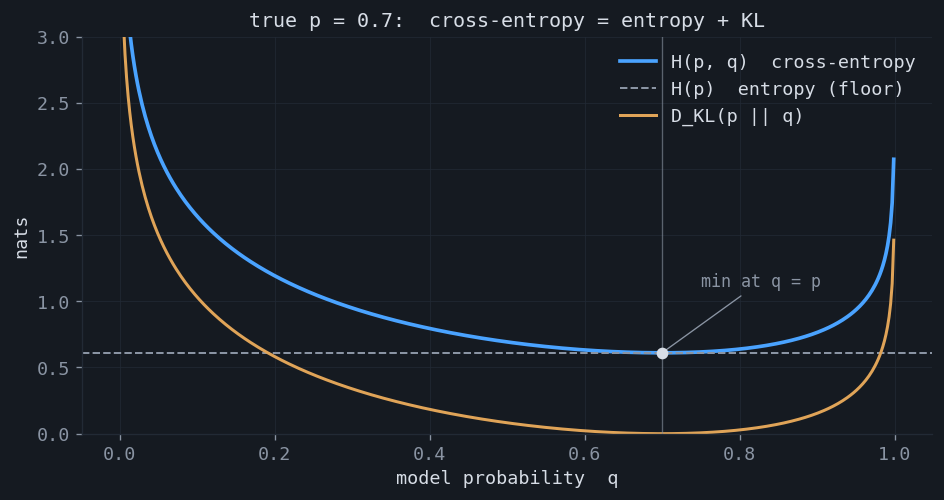

H(p,q) at q=0.4: 0.7947   ==   H(p)+KL: 0.7947


In [3]:
def bern_xent(p, q):
    return -(p*np.log(q+eps) + (1-p)*np.log(1-q+eps))

p_true = 0.7
q_grid = np.linspace(1e-3, 1-1e-3, 500)
H_pq = bern_xent(p_true, q_grid); H_p = bern_xent(p_true, p_true); KL = H_pq - H_p

fig, ax = plt.subplots(figsize=(8, 4.3))
ax.plot(q_grid, H_pq, color=ACCENT, lw=2.2, label="H(p, q)  cross-entropy")
ax.axhline(H_p, color=MUTED, ls="--", lw=1.2, label="H(p)  entropy (floor)")
ax.plot(q_grid, KL, color=ACCENT2, lw=1.8, label="D_KL(p || q)")
ax.axvline(p_true, color=MUTED, lw=0.8, alpha=0.6); ax.scatter([p_true],[H_p], color=FG, s=36, zorder=5)
ax.annotate("min at q = p", xy=(p_true, H_p), xytext=(p_true+0.05, H_p+0.5),
            color=MUTED, fontsize=10, arrowprops=dict(arrowstyle="-", color=MUTED, lw=0.8))
ax.set_xlabel("model probability  q"); ax.set_ylabel("nats"); ax.set_ylim(0, 3)
ax.set_title(f"true p = {p_true}:  cross-entropy = entropy + KL"); ax.legend(); style(ax)
plt.tight_layout(); plt.show()
qc = 0.4
print(f"H(p,q) at q={qc}: {bern_xent(p_true, qc):.4f}   ==   H(p)+KL: {H_p + (bern_xent(p_true, qc)-H_p):.4f}")

## 3. Calibration: cross-entropy sees what accuracy can't

An over-confident 3-class classifier: scale its logits by temperature $T$ and sweep.
Dividing logits by $T$ never changes the arg-max, so **accuracy is flat** — but it
reshapes the probabilities, so **cross-entropy has a clear minimum** at the honest
temperature. This is why temperature scaling is a standard calibration trick.

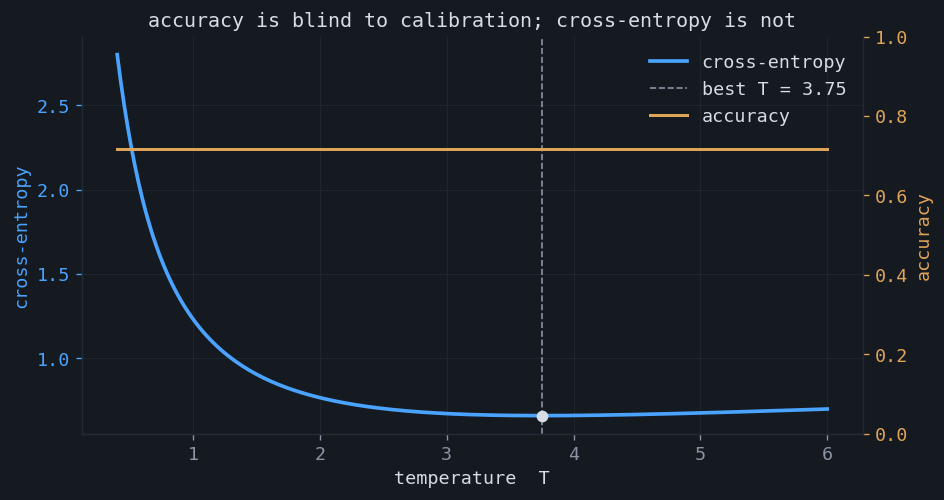

accuracy varies by only 0.0000 across all T; CE min at T=3.75


In [4]:
C, N = 3, 4000
y = rng.integers(0, C, size=N)
true_logits = np.zeros((N, C)); true_logits[np.arange(N), y] = 2.2
logits = (true_logits + rng.normal(0, 1.6, size=(N, C))) * 3.0   # overconfident

def softmax(z):
    z = z - z.max(axis=1, keepdims=True); e = np.exp(z); return e / e.sum(axis=1, keepdims=True)
def metrics_at_T(T):
    probs = softmax(logits / T)
    return -np.log(probs[np.arange(N), y] + eps).mean(), (probs.argmax(1) == y).mean()

Ts = np.linspace(0.4, 6.0, 200)
nlls = np.array([metrics_at_T(T)[0] for T in Ts])
accs = np.array([metrics_at_T(T)[1] for T in Ts])
T_star = Ts[nlls.argmin()]

fig, ax = plt.subplots(figsize=(8, 4.3))
ax.plot(Ts, nlls, color=ACCENT, lw=2.2, label="cross-entropy")
ax.axvline(T_star, color=MUTED, ls="--", lw=1, label=f"best T = {T_star:.2f}")
ax.scatter([T_star], [nlls.min()], color=FG, s=36, zorder=5)
ax.set_xlabel("temperature  T"); ax.set_ylabel("cross-entropy", color=ACCENT)
ax.tick_params(axis="y", colors=ACCENT)
ax.set_title("accuracy is blind to calibration; cross-entropy is not"); style(ax)
axr = ax.twinx()
axr.plot(Ts, accs, color=ACCENT2, lw=1.8, label="accuracy")
axr.set_ylabel("accuracy", color=ACCENT2); axr.tick_params(axis="y", colors=ACCENT2)
axr.set_ylim(0, 1); axr.grid(False); axr.spines["top"].set_visible(False)
l1, a1 = ax.get_legend_handles_labels(); l2, a2 = axr.get_legend_handles_labels()
ax.legend(l1+l2, a1+a2, loc="upper right")
plt.tight_layout(); plt.show()
print(f"accuracy varies by only {accs.max()-accs.min():.4f} across all T; CE min at T={T_star:.2f}")

## 4. Forward vs. reverse KL on a bimodal target

Approximate a two-bump target with a single Gaussian under each direction of KL.
**Forward** $D_{\mathrm{KL}}(p\|q)$ (what cross-entropy minimizes) is mode-**covering**;
**reverse** $D_{\mathrm{KL}}(q\|p)$ is mode-**seeking**.

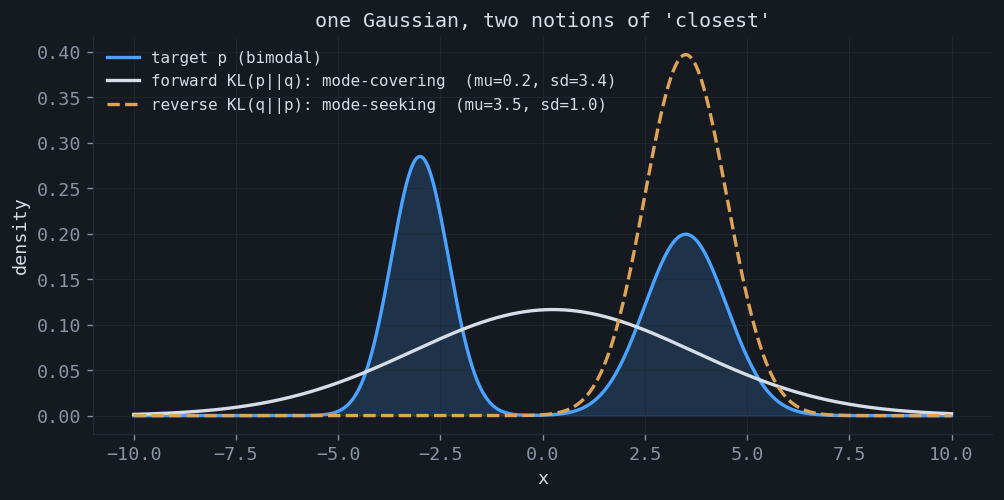

forward: mu=0.25, sd=3.43 (wide)   reverse: mu=3.50, sd=1.01 (narrow)


In [5]:
x = np.linspace(-10, 10, 2000); dx = x[1] - x[0]
def gauss(x, mu, sd): return np.exp(-0.5*((x-mu)/sd)**2) / (sd*np.sqrt(2*np.pi))
p = 0.5*gauss(x, -3.0, 0.7) + 0.5*gauss(x, 3.5, 1.0); p /= p.sum()*dx
mus = np.linspace(-5, 5, 121); sds = np.linspace(0.3, 5.0, 121)
best = {"fwd": (np.inf, None), "rev": (np.inf, None)}
for mu in mus:
    for sd in sds:
        q = gauss(x, mu, sd); q /= q.sum()*dx
        fwd = np.sum(p * np.log((p+eps)/(q+eps))) * dx
        rev = np.sum(q * np.log((q+eps)/(p+eps))) * dx
        if fwd < best["fwd"][0]: best["fwd"] = (fwd, (mu, sd))
        if rev < best["rev"][0]: best["rev"] = (rev, (mu, sd))
(mf, sf) = best["fwd"][1]; (mr, sr) = best["rev"][1]
q_fwd = gauss(x, mf, sf); q_fwd /= q_fwd.sum()*dx
q_rev = gauss(x, mr, sr); q_rev /= q_rev.sum()*dx
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.fill_between(x, p, color=ACCENT, alpha=0.18); ax.plot(x, p, color=ACCENT, lw=2.0, label="target p (bimodal)")
ax.plot(x, q_fwd, color=FG, lw=2.0, label=f"forward KL(p||q): mode-covering  (mu={mf:.1f}, sd={sf:.1f})")
ax.plot(x, q_rev, color=ACCENT2, lw=2.0, ls="--", label=f"reverse KL(q||p): mode-seeking  (mu={mr:.1f}, sd={sr:.1f})")
ax.set_xlabel("x"); ax.set_ylabel("density"); ax.set_title("one Gaussian, two notions of 'closest'")
ax.legend(fontsize=9.5); style(ax)
plt.tight_layout(); plt.show()
print(f"forward: mu={mf:.2f}, sd={sf:.2f} (wide)   reverse: mu={mr:.2f}, sd={sr:.2f} (narrow)")

## 5. Why not MSE for binary classification?

It's tempting to treat the label as a number and minimize squared error
$(\,\hat{y}-y\,)^2$. Worth being precise about why we don't:

- **It is not that MSE is "wrong."** The squared error of a probability is the
  **Brier score**, and like cross-entropy it is a *proper scoring rule* — its expected
  value is minimized when you report the true probability. (Checked below.)
- **The problem is optimization.** Put a sigmoid in front, $\,\hat{y}=\sigma(z)$, and look
  at the gradient w.r.t. the pre-activation $z$ for a positive example:

$$ \text{BCE:}\;\; \frac{\partial L}{\partial z} = \sigma(z) - y,
   \qquad
   \text{MSE:}\;\; \frac{\partial L}{\partial z} = (\sigma(z)-y)\,\sigma(z)(1-\sigma(z)). $$

The extra $\sigma'(z)=\sigma(z)(1-\sigma(z))$ in MSE goes to zero when the unit is
saturated. So a **confidently wrong** neuron ($y=1,\ \sigma(z)\approx0$) gets almost no
gradient under MSE and stops learning — while cross-entropy's gradient is $\approx 1$
there. The $\log$ in BCE exists precisely to cancel that $\sigma'$ (it is the Bernoulli
NLL).

In [6]:
# (a) both are proper scoring rules: expected loss minimized at the true probability
pi = 0.3
r = np.linspace(0, 1, 1001)
brier = pi*(r-1)**2 + (1-pi)*(r-0)**2                       # E[(r-Y)^2]
xent  = -(pi*np.log(r+eps) + (1-pi)*np.log(1-r+eps))        # E[BCE]
print(f"true pi = {pi}")
print(f"Brier minimized at r = {r[brier.argmin()]:.3f}")
print(f"BCE   minimized at r = {r[xent.argmin()]:.3f}")
print("-> both proper scoring rules, both honest at r = pi")

true pi = 0.3
Brier minimized at r = 0.300
BCE   minimized at r = 0.300
-> both proper scoring rules, both honest at r = pi


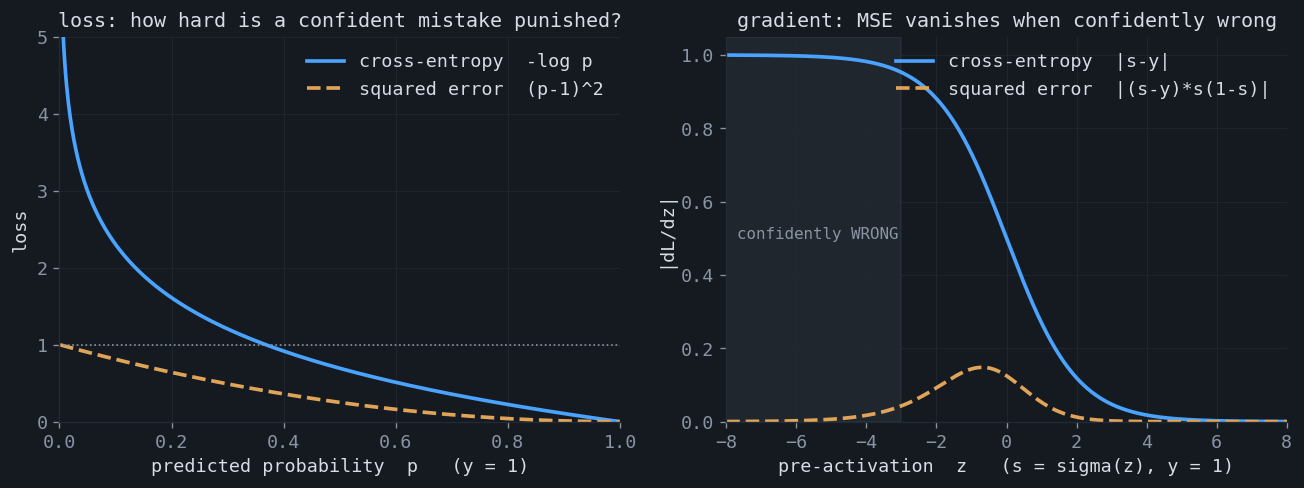

In [7]:
# (b) loss shape for a positive example, and (c) gradient wrt z
pp = np.linspace(1e-3, 1-1e-3, 600)
z  = np.linspace(-8, 8, 800); s = 1/(1+np.exp(-z)); y = 1

fig, (axL, axG) = plt.subplots(1, 2, figsize=(11, 4.2))

axL.plot(pp, -np.log(pp), color=ACCENT, lw=2.2, label="cross-entropy  -log p")
axL.plot(pp, (pp-1)**2, color=ACCENT2, lw=2.2, ls="--", label="squared error  (p-1)^2")
axL.axhline(1, color=MUTED, ls=":", lw=1)
axL.set_xlabel("predicted probability  p   (y = 1)"); axL.set_ylabel("loss")
axL.set_xlim(0,1); axL.set_ylim(0,5); axL.set_title("loss: how hard is a confident mistake punished?")
axL.legend(); style(axL)

axG.plot(z, np.abs(s-y), color=ACCENT, lw=2.2, label="cross-entropy  |s-y|")
axG.plot(z, np.abs((s-y)*s*(1-s)), color=ACCENT2, lw=2.2, ls="--", label="squared error  |(s-y)*s(1-s)|")
axG.axvspan(-8, -3, color=MUTED, alpha=0.10)
axG.annotate("confidently WRONG", xy=(-6, 0.05), xytext=(-7.7, 0.5), color=MUTED, fontsize=9.5)
axG.set_xlabel("pre-activation  z   (s = sigma(z), y = 1)"); axG.set_ylabel("|dL/dz|")
axG.set_xlim(-8,8); axG.set_ylim(0,1.05); axG.set_title("gradient: MSE vanishes when confidently wrong")
axG.legend(loc="upper right"); style(axG)
plt.tight_layout(); plt.show()

### The practical consequence

Train a single sigmoid neuron by gradient descent under each loss, starting from a
**confidently wrong** initialization, and watch how fast each escapes. Same data, same
learning rate, same start — only the loss differs.

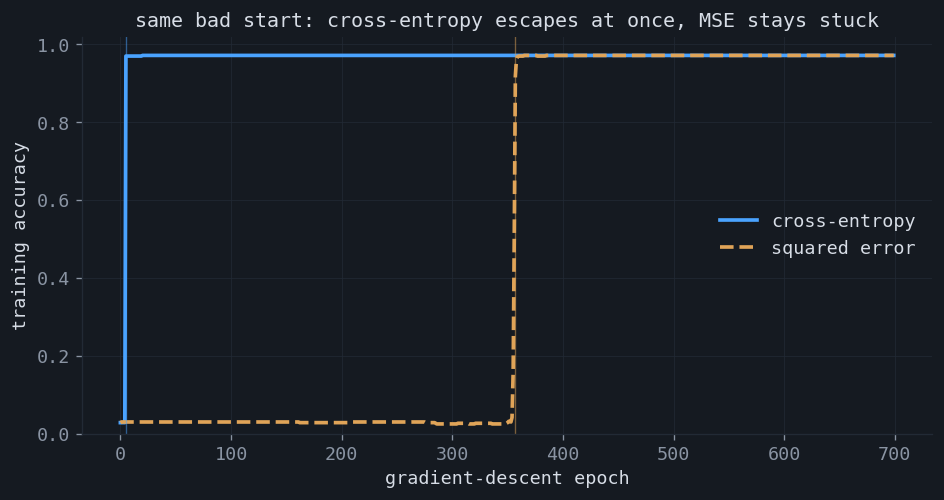

epoch to reach 90% accuracy:  cross-entropy = 5,  MSE = 357
accuracy at epoch 50:         cross-entropy = 0.972,  MSE = 0.030
MSE is trapped in the saturated region (near-zero gradient) until it slowly drifts out.


In [8]:
m = 300
xp = rng.normal( 2.0, 1.0, m); xn = rng.normal(-2.0, 1.0, m)
X = np.concatenate([xp, xn]); Y = np.concatenate([np.ones(m), np.zeros(m)])

def sigmoid(z): return 1/(1+np.exp(-z))

def train(loss, w0, b0, lr=0.5, epochs=400):
    w, b = w0, b0; accs = []
    for _ in range(epochs):
        z = w*X + b; s = sigmoid(z)
        if loss == "bce":
            dz = (s - Y)                      # clean gradient
        else:
            dz = (s - Y) * s * (1 - s)        # extra sigma'(z)
        gw = np.mean(dz * X); gb = np.mean(dz)
        w -= lr*gw; b -= lr*gb
        accs.append(np.mean((s > 0.5) == (Y > 0.5)))
    return np.array(accs)

w0, b0 = -4.0, 0.0   # confidently-wrong start (w<0 flips classes, large |w| saturates)
acc_bce = train("bce", w0, b0, epochs=700)
acc_mse = train("mse", w0, b0, epochs=700)

esc_bce = int(np.argmax(acc_bce > 0.9))
esc_mse = int(np.argmax(acc_mse > 0.9))

fig, ax = plt.subplots(figsize=(8, 4.3))
ax.plot(acc_bce, color=ACCENT, lw=2.2, label="cross-entropy")
ax.plot(acc_mse, color=ACCENT2, lw=2.2, ls="--", label="squared error")
ax.axvline(esc_bce, color=ACCENT, lw=0.8, alpha=0.5)
ax.axvline(esc_mse, color=ACCENT2, lw=0.8, alpha=0.5)
ax.set_xlabel("gradient-descent epoch"); ax.set_ylabel("training accuracy")
ax.set_ylim(0, 1.02); ax.set_title("same bad start: cross-entropy escapes at once, MSE stays stuck")
ax.legend(loc="center right"); style(ax)
plt.tight_layout(); plt.show()
print(f"epoch to reach 90% accuracy:  cross-entropy = {esc_bce},  MSE = {esc_mse}")
print(f"accuracy at epoch 50:         cross-entropy = {acc_bce[50]:.3f},  MSE = {acc_mse[50]:.3f}")
print("MSE is trapped in the saturated region (near-zero gradient) until it slowly drifts out.")

## Takeaways

- Cross-entropy is the **negative log-likelihood** of your model; the coin shows it in
  two lines.
- $H(p,q) = H(p) + D_{\mathrm{KL}}(p\|q)$, so minimizing it is **minimizing KL** to the data.
- It scores **calibration**, not just correctness — accuracy can't see that.
- The KL direction it minimizes (forward) is **mode-covering**.
- **MSE isn't incorrect** (it's a proper scoring rule too), but on a sigmoid its
  gradient **vanishes when the model is confidently wrong**, so cross-entropy is the
  better optimization target for classification.